## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence
from axion_production.electron_scattering.electron_scattering_analysis import ElectronScatteringModel

## Initialize the Axion Electron Scattering Model

In [3]:
file_path = '../Maxim-data/Distributions_e_scat.dat'  # Set the correct file path
axionModel = ElectronScatteringModel(file_path)
parameterDependence = ParametersAxionMassDependence("electron_scattering", file_path)

In [4]:
# --- Find ΔN_eff: using Parameters A, b and mu fitted to the original distribution
N_distributions = parameterDependence.get_number_of_distributions()

# --- Necessary list and loop
delta_Neff_points_arr = []
mass_axion_points_arr = []
decay_cons_points_arr = []

for index in range(0, N_distributions):
    # return axion mass and fa
    axion_mass = parameterDependence.get_axion_masses()[index]
    decay_cons = parameterDependence.get_decay_constants()[index]

    # Find parameters A, b, mu after comparing to original distribution
    fit_params = parameterDependence.fit_single_distribution(index, dist="f(q)_q2")

    # calculate delta N_eff
    delta_N_eff = axionModel.calculate_delta_n_eff(axion_mass, parameters_arr=fit_params)

    # appending
    delta_Neff_points_arr.append(delta_N_eff)
    mass_axion_points_arr.append(axion_mass)
    decay_cons_points_arr.append(decay_cons)

In [5]:
# --- Find ΔN_eff: using analytical formula for A(log(m_a)), b(log(m_a)) and mu(log(m_a))
# axion masses
low_axion_mass = min(mass_axion_points_arr)
max_axion_mass = max(mass_axion_points_arr)
Nums = 500
axion_masses = np.logspace(np.log10(low_axion_mass), np.log10(max_axion_mass), num=Nums)  # [eV]

# --- find the values of Delta N_eff
delta_N_eff_arr = []
decay_constants_arr = []
for m_a in axion_masses:
    val_fa = axionModel.calculate_fa(m_a)
    
    # calculate delta N_eff
    delta_N_eff = axionModel.calculate_delta_n_eff(m_a)

    # appending
    delta_N_eff_arr.append(delta_N_eff)
    decay_constants_arr.append(val_fa)

## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

This plot compares $\Delta N_{\mathrm{eff}}$ computed from the **analytical formula** and from **directly extracted distributions** as functions of:
- **Axion mass** $m_a$ (left panel).
- **Decay constant** $f_a$ (right panel).

### **Features**
- **Comparison of two methods**: analytical (solid line) vs. distribution-based (scatter points).
- **Planck 2018 constraint** added as a reference (dashed line and shaded region).

This visualization checks the consistency between the interpolated and direct methods, confirming that the functional approximations for $A(m_a), b(m_a), \mu(m_a)$ correctly describe the axion distribution and its effect on $\Delta N_{\mathrm{eff}}$.

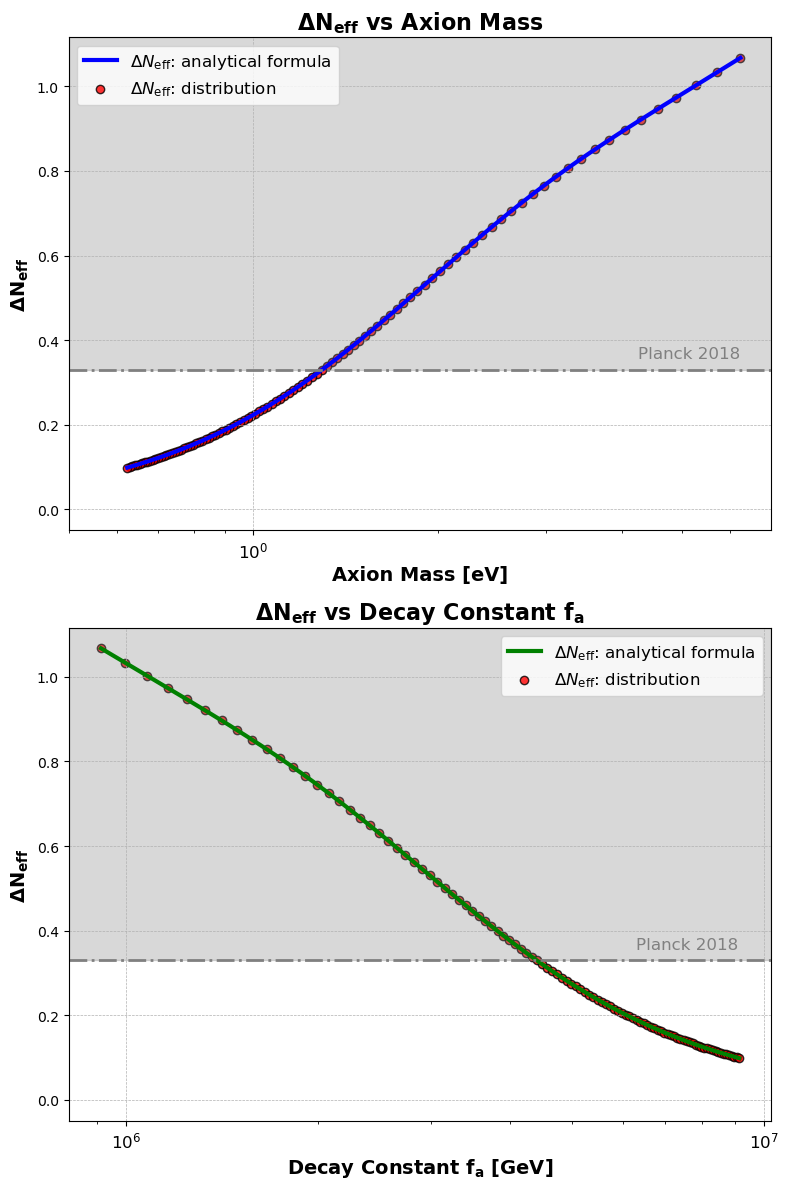

In [15]:
# Create the figure and two subplots with improved aesthetics
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# ---------------------------------------------------- FIRST PART OF PLOT ---------------------------------------------------- #
# First plot: m_a vs Delta_N_eff with larger font size and thicker lines
axs[0].plot(axion_masses, delta_N_eff_arr, color='b', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
axs[0].scatter(mass_axion_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs[0].set_xscale('log')
axs[0].set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
axs[0].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[0].set_title(r'$\bf \Delta N_{eff}$ vs Axion Mass', fontsize=16, fontweight='bold')
axs[0].grid(True, linestyle='--', linewidth=0.5)
axs[0].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[0].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[0].text(axion_masses[-1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[0].get_ylim()
xmin, xmax = axs[0].get_xlim()
xmin = 0.5
axs[0].set_xlim(xmin, xmax)
axs[0].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[0].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[0].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[0].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs[1].plot(decay_constants_arr, delta_N_eff_arr, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
axs[1].scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs[1].set_xscale('log')
axs[1].set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs[1].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[1].set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs[1].grid(True, linestyle='--', linewidth=0.5)
axs[1].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[1].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[1].text(decay_constants_arr[1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[1].get_ylim()
xmin, xmax = axs[1].get_xlim()
xmin = axionModel.calculate_fa(7.0)
axs[1].set_xlim(xmin, xmax)
axs[1].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[1].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[1].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[1].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('delta_N_eff_vs_axion_mass_and_decay_constant_new.png', format='png', dpi=300)
# plt.close()

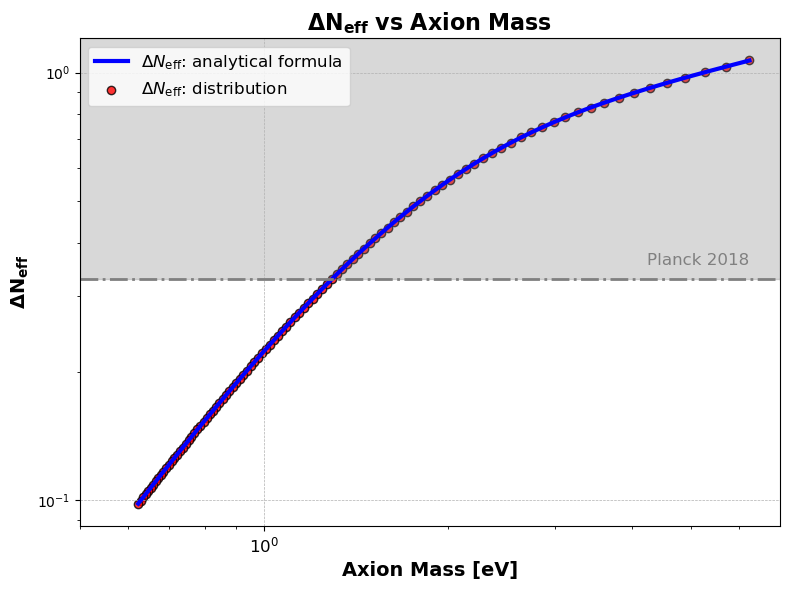

In [16]:
# ------------- LogLog Plot: \Delta N_eff vs m_a
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
ax.plot(axion_masses, delta_N_eff_arr, color='b', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
ax.scatter(mass_axion_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')

# --- Other settings
# Set xy-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title with bold text
ax.set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
ax.set_title(r'$\bf \Delta N_{eff} \ vs \ Axion \ Mass$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
ax.text(axion_masses[-1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
xmin = 0.5
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)
# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Extra relativistic degrees of freedom and axion mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$ with fit

Now we will try to find the general fit: so find out the $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$,
so we try to use polynomial fit, which will coincides with analytical formula.

In [18]:
# --- Find fit: Delta N_eff(m_a)
# Fit a 15th degree polynomial (you can adjust the degree if necessary)
degree = 13
coeffs = np.polyfit(np.log(axion_masses), delta_N_eff_arr, degree)

# Create a polynomial function based on the fitted coefficients
polynomial_of_delta_n_eff = np.poly1d(coeffs)

# Generate fitted values for smooth plotting
min_axion_mass_fit = 0.623  # [eV]
max_axion_mass_fit = 6.23    # [eV]
axion_masses_fit = np.logspace(np.log10(min_axion_mass_fit), np.log10(max_axion_mass_fit), num=1000)  # [eV]
delta_N_eff_fit_arr = polynomial_of_delta_n_eff(np.log(axion_masses_fit))

# --- Decay List
decay_constants_fit_arr = axionModel.calculate_fa(axion_masses_fit)

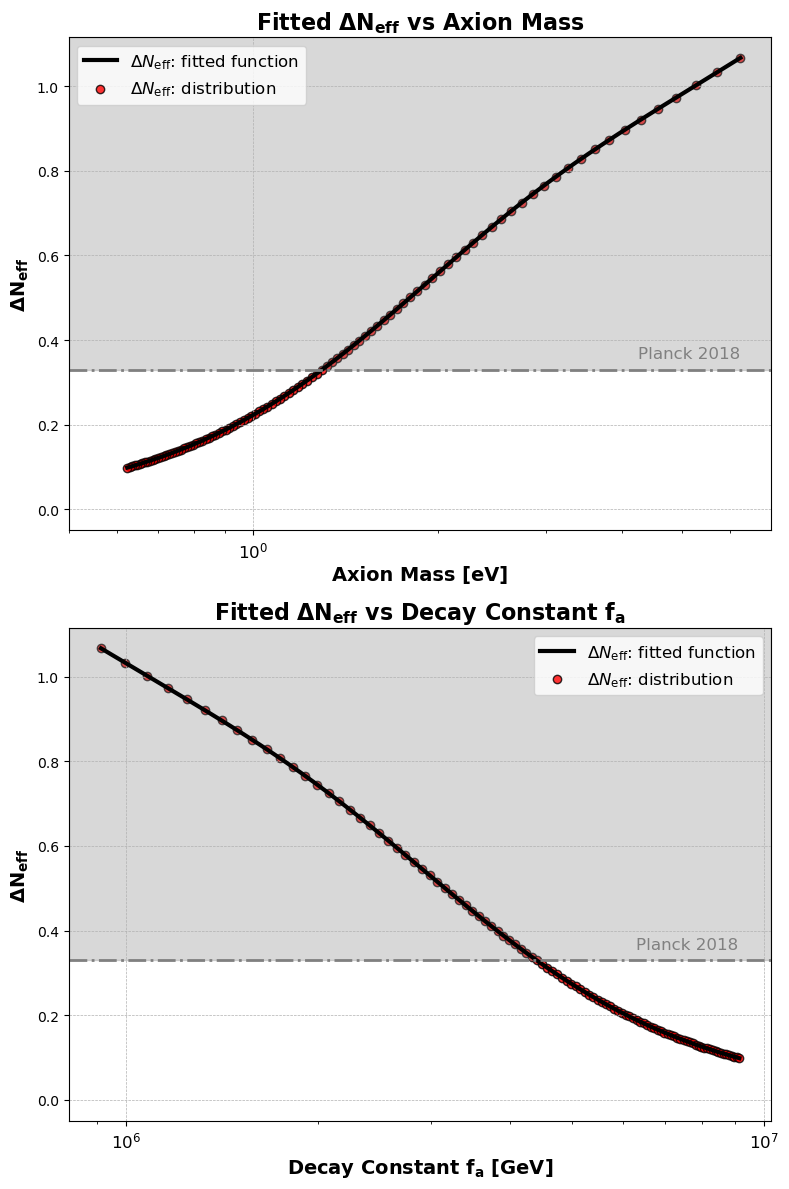

In [19]:
# Create the figure and two subplots with improved aesthetics
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# ---------------------------------------------------- FIRST PART OF PLOT ---------------------------------------------------- #
# First plot: m_a vs Delta_N_eff with larger font size and thicker lines
axs[0].plot(axion_masses_fit, delta_N_eff_fit_arr, color='black', lw=3, label=r'$\Delta N_{\rm{eff}}$: fitted function')
axs[0].scatter(mass_axion_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs[0].set_xscale('log')
axs[0].set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
axs[0].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[0].set_title(r'$\bf Fitted \ \Delta N_{eff}$ vs Axion Mass', fontsize=16, fontweight='bold')
axs[0].grid(True, linestyle='--', linewidth=0.5)
axs[0].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[0].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[0].text(axion_masses[-1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[0].get_ylim()
xmin, xmax = axs[0].get_xlim()
xmin = 0.5
axs[0].set_xlim(xmin, xmax)
axs[0].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[0].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[0].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[0].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs[1].plot(decay_constants_fit_arr, delta_N_eff_fit_arr, color='black', lw=3, label=r'$\Delta N_{\rm{eff}}$: fitted function')
axs[1].scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs[1].set_xscale('log')
axs[1].set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs[1].set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs[1].set_title(r'$\bf Fitted \ \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs[1].grid(True, linestyle='--', linewidth=0.5)
axs[1].legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs[1].axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs[1].text(decay_constants_arr[1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs[1].get_ylim()
xmin, xmax = axs[1].get_xlim()
xmin = axionModel.calculate_fa(7.0)
axs[1].set_xlim(xmin, xmax)
axs[1].set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs[1].fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs[1].xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs[1].tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('delta_N_eff_vs_axion_mass_and_decay_constant_new.png', format='png', dpi=300)
# plt.close()

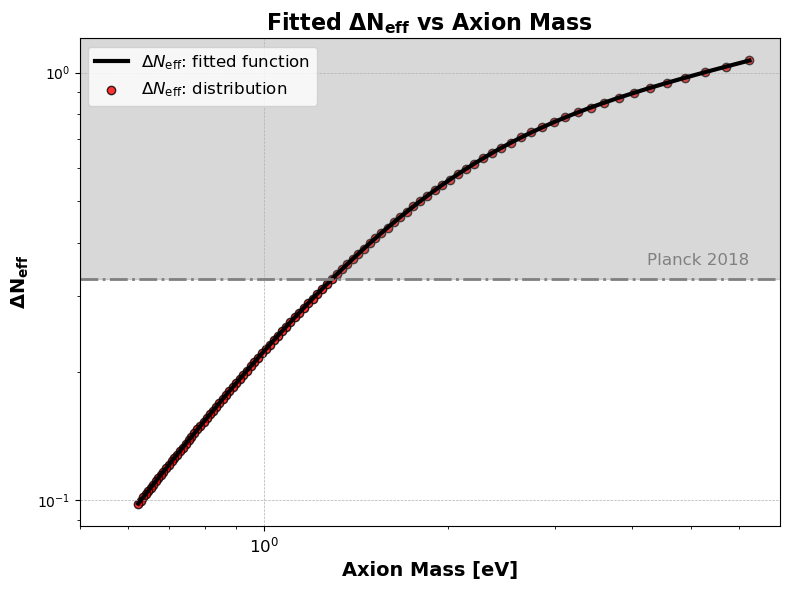

In [21]:
# ------------- LogLog Plot: \Delta N_eff vs m_a
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
ax.plot(axion_masses_fit, delta_N_eff_fit_arr, color='black', lw=3, label=r'$\Delta N_{\rm{eff}}$: fitted function')
ax.scatter(mass_axion_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')

# --- Other settings
# Set xy-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title with bold text
ax.set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
ax.set_title(r'$\bf Fitted \ \Delta N_{eff} \ vs \ Axion \ Mass$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
ax.text(axion_masses[-1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
xmin = 0.5
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)
# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [22]:
print(polynomial_of_delta_n_eff)

          13            12           11           10            9
0.001176 x  - 0.009351 x  + 0.02883 x  - 0.03624 x  - 0.002551 x
            8            7             6           5           4
 + 0.03652 x + 0.001255 x + 0.0006105 x - 0.03444 x - 0.07131 x
             3          2
 + 0.007832 x + 0.2168 x + 0.3588 x + 0.223


In [23]:
polynomial_of_delta_n_eff

poly1d([ 0.00117621, -0.00935135,  0.02883079, -0.03623783, -0.00255083,
        0.03652366,  0.00125484,  0.00061048, -0.03443676, -0.07130811,
        0.00783158,  0.21679073,  0.35879559,  0.2230367 ])

In [24]:
coeffs

array([ 0.00117621, -0.00935135,  0.02883079, -0.03623783, -0.00255083,
        0.03652366,  0.00125484,  0.00061048, -0.03443676, -0.07130811,
        0.00783158,  0.21679073,  0.35879559,  0.2230367 ])

In [27]:
# --- Check the differences between ΔN_eff_fit and ΔN_eff_points ---
print(f"{'Axion Mass [eV]':<20}{'ΔN_eff (Best)':>20}{'ΔN_eff (Fit)':>20}{'Rel. Diff. [%]':>20}")
print("=" * 80)

for i in range(N_distributions):
    m_a = mass_axion_points_arr[i]  # Axion mass in eV
    N_eff = delta_Neff_points_arr[i]  # Best values from distribution
    N_eff_fit = polynomial_of_delta_n_eff(np.log(m_a))  # Fitted function values

    # Compute relative difference in percentage
    rel_diff = 100 * abs(N_eff - N_eff_fit) / abs(N_eff) if N_eff != 0 else 0

    print(f"{m_a:<20.6e}{N_eff:>20.6e}{N_eff_fit:>20.6e}{rel_diff:>20.6f}")

Axion Mass [eV]            ΔN_eff (Best)        ΔN_eff (Fit)      Rel. Diff. [%]
6.230250e+00                1.067534e+00        1.067542e+00            0.000790
5.711062e+00                1.033500e+00        1.033477e+00            0.002205
5.271750e+00                1.002384e+00        1.002412e+00            0.002810
4.895196e+00                9.736270e-01        9.736157e-01            0.001154
4.568850e+00                9.466479e-01        9.466521e-01            0.000450
4.283297e+00                9.211566e-01        9.211704e-01            0.001491
4.031338e+00                8.968933e-01        8.968713e-01            0.002452
3.807375e+00                8.735176e-01        8.735083e-01            0.001063
3.606987e+00                8.508955e-01        8.508876e-01            0.000928
3.426638e+00                8.288539e-01        8.288645e-01            0.001279
3.263464e+00                8.073207e-01        8.073363e-01            0.001930
3.115125e+00                